In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
import glob as glob
import os
from importlib import reload
%matplotlib inline
import sys
sys.path.append("modules")
sys.path.append('/home/labs/barkailab/vovam/Mammalian/Analysis_modules')
import reading_data as rd
from collections import defaultdict
import pyBigWig as pw
import pysam
from itertools import groupby
from Bio import motifs
import logomaker
from Bio import Align
from Bio.Seq import Seq
%config InlineBackend.figure_format='retina'
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import seaborn.objects as so
import logomaker
import seaborn
from bs4 import BeautifulSoup
from matplotlib import style
from multiprocessing import Pool, cpu_count


/home/labs/barkailab/vovam/miniconda/envs/iran/lib/python3.11/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
metadata = pd.read_parquet('metadata/metadata.parquet').loc[:, ['index', 'NormBG', 'AverageBw', 'peaks_w_summits', 'BigWig']].fillna('None')
metadata.peaks_w_summits = metadata.peaks_w_summits.apply(lambda x: os.path.join('data/combined_threshed_peaks_wsummits/', x.split('/')[-1]))
metadata.AverageBw = metadata.AverageBw.apply(lambda x: os.path.join('data/AverageBw/', x.split('/')[-1]))
metadata.NormBG = metadata.NormBG.apply(lambda x: [os.path.join('data/NormBG/', k.split('/')[-1]) for k in x])
metadata.BigWig = metadata.BigWig.apply(lambda x: [os.path.join('data/SampleBW/', k.split('/')[-1]) for k in x])

In [3]:
bw_d = metadata.filter(regex='nmumg', axis=0).filter(regex='lig|lbd$|dbd|400', axis=0).drop(['nmumg_hgr_dbd', 'nmumg_mar_dlbd_dn400'], axis=0).filter(regex='gr|pr',axis=0).loc[:,'BigWig'].to_dict()
prdbdlbd = glob.glob('data/SampleBW/PR_DBDLBD*')
grdbdlbd = glob.glob('data/SampleBW/GR_DBDLBD*')
bw_d['pr_dbdlbd'] = prdbdlbd
bw_d['gr_dbdlbd'] = grdbdlbd


In [4]:
pr_peaks = ['data/combined_threshed_peaks_wsummits/nmumg_hpr_del_lbd_fc10.bed',
           'data/combined_threshed_peaks_wsummits/nmumg_hpr_dbd_fc10.bed',
           'data/DBD_LBDpeaks/PRDBDLBD_fc10.bed',
            'data/combined_threshed_peaks_wsummits/nmumg_hgr_dlbd_fc10.bed',
            'data/combined_threshed_peaks_wsummits/nmumg_hgr_dbd_fc10.bed',
                       'data/DBD_LBDpeaks/GRDBDLBD_fc10.bed',
                        'data/combined_threshed_peaks_wsummits/nmumg_hgr_wt_lig_fc10.bed',
                                    'data/combined_threshed_peaks_wsummits/nmumg_hpr_wt_lig_fc10.bed'
           ]

In [5]:
loaded_peaks = pd.concat([pd.read_csv(x, delimiter='\t', header=None).iloc[:, [0,1,2,3]] for x in pr_peaks], axis=0)
loaded_peaks.columns = ['Chromosome', 'Start', 'End', 'Name']
remove_clusters = pr.PyRanges(loaded_peaks).cluster(slack=200).df.groupby('Cluster').agg(lambda x: list(x))
remove_clusters.Chromosome = remove_clusters.Chromosome.apply(lambda x: x[0]) 
remove_clusters.Start = remove_clusters.Start.apply(lambda x: max(x) if len(x)>0 else x[0])
remove_clusters.End = remove_clusters.End.apply(lambda x: min(x) if len(x)>0 else x[0]) 

remove_clusters.loc[:, 'Mid'] = ((remove_clusters.End - remove_clusters.Start) + remove_clusters.Start).astype(np.int32)

In [6]:
bigwigs = np.concatenate([x for x in bw_d.values()])

In [7]:
window = 300


In [8]:
def fetch_signal(args):
    chrom, mid, bw_paths = args
    results = []
    for bw_path in bw_paths:
        with pw.open(bw_path) as bw:
            val = bw.stats(chrom, mid - window, mid + window, type='sum', numpy=True, exact=True)[0]
        results.append(val)
    return results

args = [(chrom, mid, bigwigs) for chrom, mid in remove_clusters[['Chromosome', 'Mid']].values]

with Pool(processes=cpu_count()) as pool:
    results = pool.map(fetch_signal, args)

final_df = pd.DataFrame(results, columns=[bw.split('/')[-1] for bw in bigwigs])

In [9]:
coll = ['hGR_WT_lig_1_S26.bam.bw',
 'hGR_WT_lig_2_S27.bam.bw',
 'hGR_WT_lig_3_S64.bam.bw',
 'hGR_WT_lig_4_S28.bam.bw',
 'hPR_WT_lig_1_S26.bam.bw',
 'hPR_WT_lig_2_S27.bam.bw',
 'hPR_WT_lig_3_S28.bam.bw',
 'hGR_dLBD_1_S12.bam.bw',
 'hGR_dLBD_2_S13.bam.bw',
 'hGR_dLBD_4_S15.bam.bw',
'hPR_del_LBD_1_S36.bam.bw',
 'hPR_del_LBD_2_S37.bam.bw',
 'hPR_del_LBD_3_S38.bam.bw',
 'NMuMG_hGR_dLBD_dN400_1_S107.bam.bw',
 'NMuMG_hGR_dLBD_dN400_2_S108.bam.bw',
 'NMuMG_hGR_dLBD_dN400_4_S110.bam.bw',
 'NMuMG_hPR_DBD_1_S115.bam.bw',
 'NMuMG_hPR_DBD_2_S116.bam.bw',
 'NMuMG_hPR_DBD_3_S117.bam.bw',
 'NMuMG_hPR_DBD_4_S118.bam.bw',

 'GR_DBDLBD_3_S57.bam.bw',
 'GR_DBDLBD_1_S55.bam.bw',
 'GR_DBDLBD_2_S56.bam.bw',
        'PR_DBDLBD_1_S61.bam.bw',
 'PR_DBDLBD_3_S63.bam.bw',
 'PR_DBDLBD_2_S62.bam.bw',]

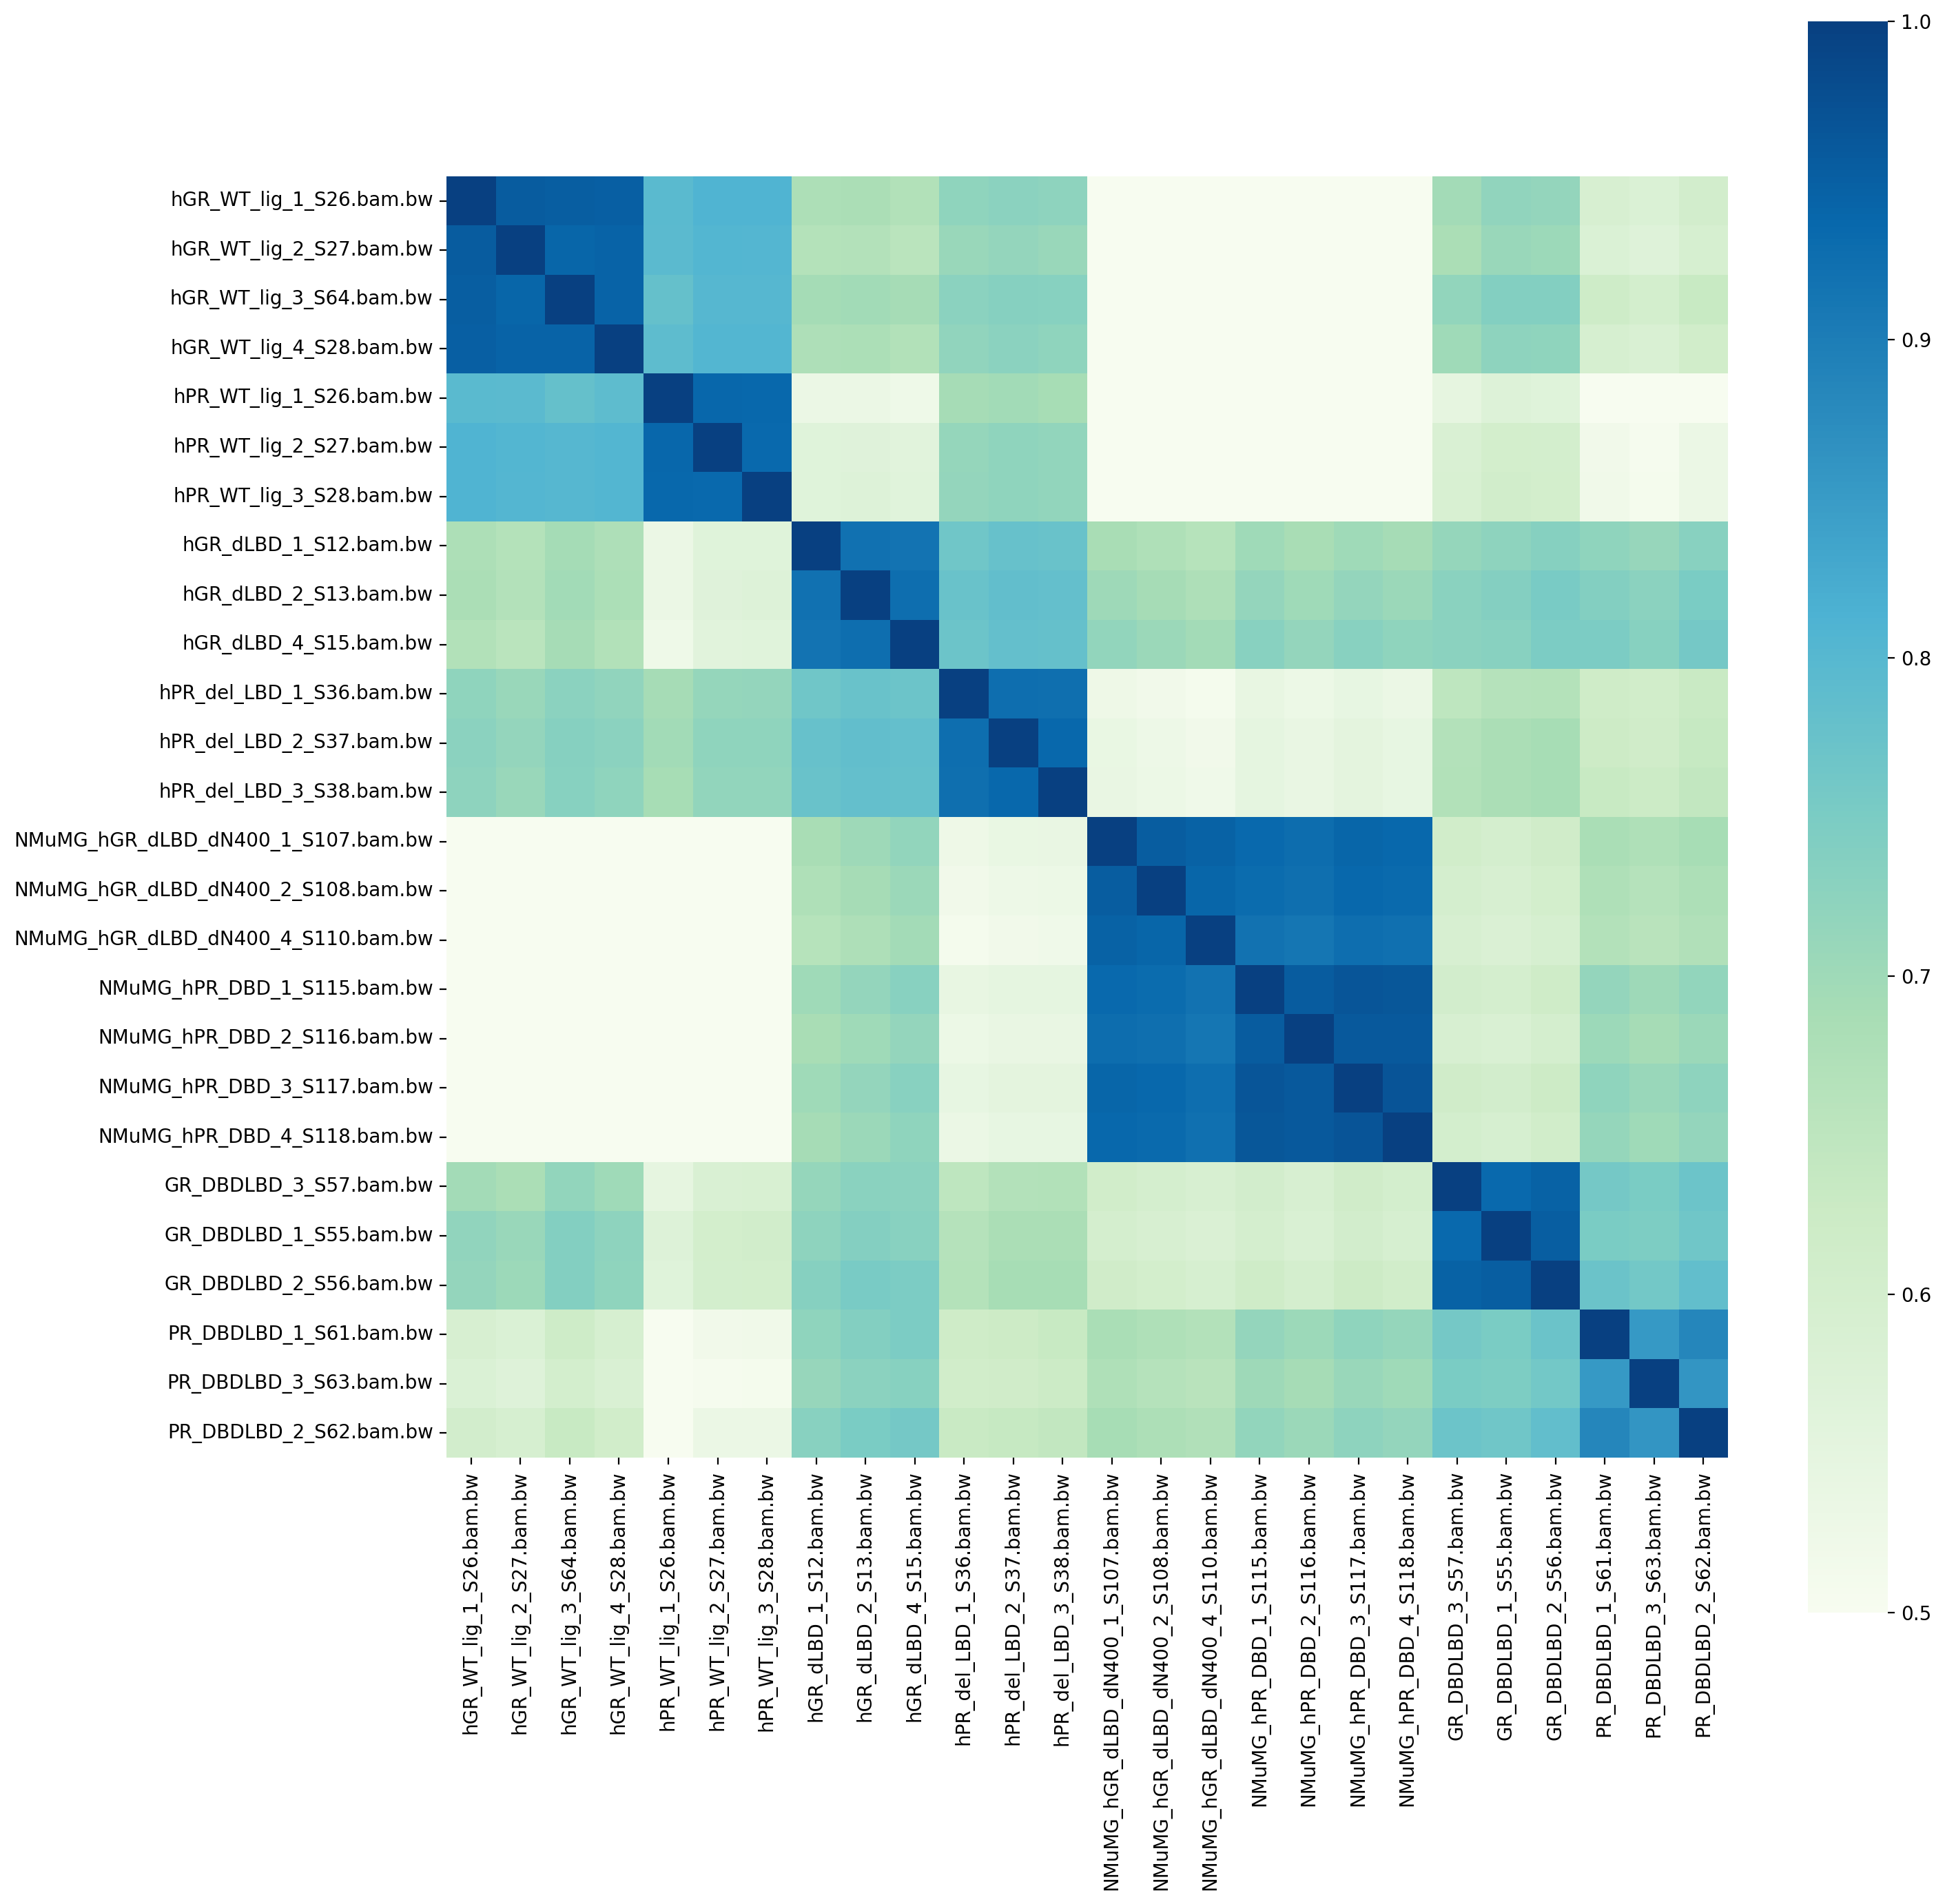

In [10]:
fig, ax = plt.subplots(1, figsize=(15,15))
sns.heatmap(final_df.loc[:, coll].corr(), annot=False, square=True, cmap='GnBu', vmin=0.5)
fig.savefig('figures/Supp/S4.pdf')